In [3]:
# 필요한 module import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# 사용하는 모델
from sklearn import linear_model
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# Ozone데이터를 이용해서
# 결측치 삭제, 이상치 삭제로 데이터를 정제하고
# 정규화 처리 당연히 진행
# LinearRegression Model을 구현해서
# 태양광 310, 바람 15, 온도 80일 경우 오존량을 Linear Regression 예측
# KNN 모델을 생성해서
# KNN을 이용해서 똑같은 데이터에 대한 예측 진행!

In [ ]:
# 1. Raw Data Loading
ozone = pd.read_csv('/content/ozone.csv')

df = ozone[['Solar.R', 'Wind', 'Temp', 'Ozone']]
display(df)

In [12]:
# 2. 데이터 전처리
# 2-1. 결측치(지금은 삭제처리)
new_df = df.dropna(how='any', inplace=False)
# 2-2. 이상치(지금은 삭제처리)
zscore_threshold = 1.8
df1 = new_df.loc[np.abs(stats.zscore(new_df['Ozone'])) <= zscore_threshold]
# 3. 정규화
# 3-1. 데이터 분리부터 해야 처리하기 편해요!
x_data = df1.drop('Ozone',
                  axis=1,
                  inplace=False).values
t_data = df1['Ozone'].values.reshape(-1,1)
scaler_x = MinMaxScaler()
scaler_t = MinMaxScaler()
scaler_x.fit(x_data)
scaler_t.fit(t_data)
x_data_norm = scaler_x.transform(x_data)
t_data_norm = scaler_t.transform(t_data)


In [25]:
test_data = np.array([[310, 15, 80]])

# Linear Regression Model (sklearn - 정규화 하지 않은 데이터 이용)
sklearn_model_1 = linear_model.LinearRegression()
sklearn_model_1.fit(x_data,
                    t_data)
print(sklearn_model_1.predict(test_data))  # [[38.26325246]]

# Linear Regression Model (sklearn - 정규화 데이터 이용)
sklearn_model_2 = linear_model.LinearRegression()
sklearn_model_2.fit(x_data_norm,
                    t_data_norm)
result = sklearn_model_2.predict(scaler_x.transform(test_data))
print(scaler_t.inverse_transform(result)) # [[38.26325246]]

# KNN Model (정규화 하지 않은 데이터 이용)
knn_regressor_1 = KNeighborsRegressor(n_neighbors=2)
knn_regressor_1.fit(x_data, t_data)
result_knn_1 = knn_regressor_1.predict(scaler_x.transform(test_data))
print(result_knn_1)   # [[25.5]]

# KNN Model (정규화 데이터 이용)
knn_regressor_2 = KNeighborsRegressor(n_neighbors=2)
knn_regressor_2.fit(x_data_norm, t_data_norm)
result_knn_2 = knn_regressor_2.predict(scaler_x.transform(test_data))
print(scaler_t.inverse_transform(result_knn_2))   # [[39.5]]

[[38.26325246]]
[[38.26325246]]
[[2.5]]
[[33.]]


In [ ]:
# 우리 Ozone데이터를 수정해서 사용할꺼예요!
# 원본데이터가 가지고 있는 결측치와 이상치를 모두 삭제하지 말고
# 수정해서 사용할꺼예요!
# 이렇게 수정된 데이터를 이용해서 sklean의 Linear Regression과
# Tensorflow Keras를 이용해서 학습시키고 특정 데이터로 예측을 진행
# 테스트 데이터는 test_data = np.array([[310, 15, 80]])를 이용.

# 이렇게 해 보아요!
# 1. 독립변수에 대한 결측치는 median으로 처리
# 2. 독립변수에 대한 이상치는 mean으로 처리
# 3. 종속변수에 대한 이상치는 검출한 후 mean으로 처리
# 4. 정규화 진행
# 5. 종속변수에 대한 결측치는 KNN을 이용해서 예측값으로 처리
# 결과값은...
# sklearn result : [[38.75927452]]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD

# 1. Training Data Set
x_data = np.array([1,3,5,7,10,13,30]).reshape(-1,1)
t_data = np.array([0,0,0,0,1,1,1]).reshape(-1,1)

# 2. Model 구현
model = Sequential()
model.add(Flatten(input_shape=(1,)))
model.add(Dense(units=1,
                activation='linear'))
model.compile(optimizer=SGD(learning_rate=1e-4),
              loss='mse')

# 3. 학습
model.fit(x_data,
          t_data,
          epochs=1000,
          verbose=1)

In [33]:
# 4. 예측
result = model.predict(np.array([[9]]))
print(result)  # [[0.58491766]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.37922907]]


In [ ]:
# Logistic Regression의 이해!(그림으로 이해!)
# mglearn library를 설치하고 사용해 보아요!
# colab을 사용하면 CPU, Memory, Disk를 제공받아요!
# 제공받은 Disk에 Ubuntu Linux가 설치되어서 제공되요!
# 특정 library를 설치하려면 pip를 이용해야 해요!
!pip install mglearn

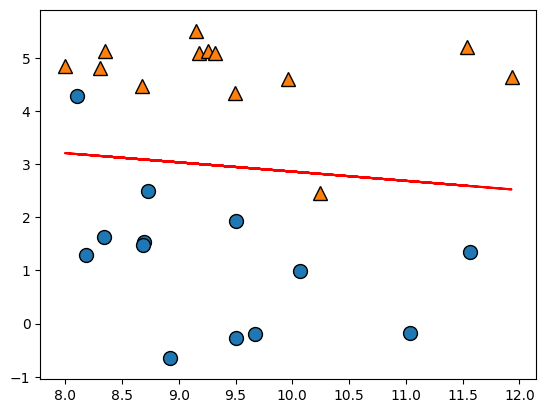

In [41]:
import numpy as np
from sklearn import linear_model
import mglearn
import matplotlib.pyplot as plt

# 1. Training Data Set
x_data, t_data = mglearn.datasets.make_forge()
# print(x_data)  # 2차원 0번째 컬럼을 x축 좌표로, 1번째 컬럼을 y축 좌표로.
# plt.scatter(x_data[:,0], x_data[:,1])
# plt.show()
# print(t_data)
mglearn.discrete_scatter(x_data[:,0], x_data[:,1], t_data)


# Linear Regression 모델을 만들고 학습까지 시켜보아요!
model = linear_model.LinearRegression()
model.fit(x_data[:,0].reshape(-1,1),
          x_data[:,1].reshape(-1,1))
# 우리 모델이 생성되고 당연히 1차 직선으로 생성되요!
# 당연히 w와 b가 생성될꺼구요
# 이 값을 이용해서 직선을 그려보아요!
plt.plot(x_data[:,0],
         x_data[:,0]*model.coef_.ravel() + model.intercept_.ravel(),
         color='r')
plt.show()

In [43]:
# 이번에는 admission dataset을 이용해서
# Logistic Regression을 구현해 보아요!

# 필요한 모듈 import
%reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
# 결측치가 있으면 삭제
# 이상치(지대점)가 있으면 처리 -> 처리안할께요. (실제데이터라고 가정)
# 정규화.(MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler

# 모델 구현(2가지 방식으로)
# 1. sklearn으로 구현
# 2. Tensorflow Keras로 구현
from sklearn import linear_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD


Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [ ]:
# 1. Raw Data Loading
df = pd.read_csv('/content/admission.csv')
display(df) # 400 rows × 4 columns

In [50]:
# 2. 데이터 전처리
# 2-1. 결측치 처리
print(df.isnull().sum())  # 확인결과 결측치는 없어요!
# 2-2. 이상치 처리(확인만 할꺼예요!)
# fig = plt.figure()

# ax_admission = fig.add_subplot(1,4,1)
# ax_gre = fig.add_subplot(1,4,2)
# ax_gpa = fig.add_subplot(1,4,3)
# ax_rank = fig.add_subplot(1,4,4)

# ax_admission.boxplot(df['admit'].values)
# ax_gre.boxplot(df['gre'].values)
# ax_gpa.boxplot(df['gpa'].values)
# ax_rank.boxplot(df['rank'].values)

# plt.tight_layout()
# plt.show()

# 2-3. 정규화처리
x_data = df.drop('admit', axis=1, inplace=False).values
t_data = df['admit'].values.reshape(-1,1)
scaler = MinMaxScaler()
scaler.fit(x_data)
x_data_norm = scaler.transform(x_data)

admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [53]:
# Model 구현
# sklearn으로 구현
sklearn_model = linear_model.LogisticRegression()
sklearn_model.fit(x_data_norm,
                  t_data.ravel())  # Logistic은 t_data 입력시 1차원으로 입력
# 예측 => (600, 3.8, 1)  => 합격할까요?
sklearn_result = sklearn_model.predict(scaler.transform(np.array([[600,3.8,1]])))
sklearn_result_proba = sklearn_model.predict_proba(scaler.transform(np.array([[600,3.8,1]])))
print(sklearn_result)
print(sklearn_result_proba)

[1]
[[0.45453933 0.54546067]]


In [ ]:
# Tensorflow Keras model 구현
keras_model = Sequential()
keras_model.add(Flatten(input_shape=(3,)))
keras_model.add(Dense(units=1,
                      activation='sigmoid'))
keras_model.compile(optimizer=SGD(learning_rate=1e-4),
                    loss='binary_crossentropy')
keras_model.fit(x_data_norm,
                t_data,
                epochs=500,
                verbose=1)


In [55]:
keras_reuslt = keras_model.predict(scaler.transform(np.array([[600,3.8,1]])))
print(keras_reuslt)  # [[0.5055724]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.5055724]]
